## 第7章: 指令微调

In [1]:
from importlib.metadata import version

pkgs = [
    "numpy",       # PyTorch & TensorFlow dependency
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

numpy version: 2.4.0
matplotlib version: 3.10.8
tiktoken version: 0.12.0
torch version: 2.9.1
tqdm version: 4.67.1
tensorflow version: 2.20.0


### 7.1 指令微调

大模型的预训练过程本质上是在做一种“逐词生成”的训练，模型每次根据已有上下文预测下一个词（token）。因此，经过预训练的模型通常很擅长文本续写与补全，但并不擅长理解并遵循人类的指令。本章的目标就是让模型在“按指令完成任务”这件事上表现得更好。

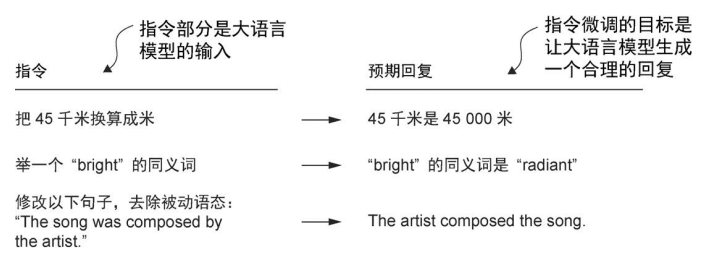

### 7.2 为有监督指令微调准备数据集

我们将从教材配套的 GitHub 仓库下载并保存指令数据集到本地，然后把这个 JSON 文件读取并解析成 Python 可直接使用的数据结构，方便后续进行数据预处理与模型训练。

In [2]:
import json
import os
import requests


def download_and_load_file(file_path, url):
    # 如果本地没有文件就从 url 下载保存，然后读取并解析 JSON，返回 Python 数据对象。
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


我们从上面的 JSON 文件加载得到的 data 列表中，每一条数据（每个元素）都是一个字典。

In [3]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


'input' 字段也可能是空的。

In [4]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


指令微调常被称为“有监督的指令微调”，因为它使用的数据集会明确给出输入和输出的配对关系，模型的训练目标就是学习从输入生成对应输出。将这些数据条目整理成大模型可用的输入文本也有多种写法，下面的图展示了两种示例格式，分别用于训练 Alpaca 和 Phi-3 这两类大模型。

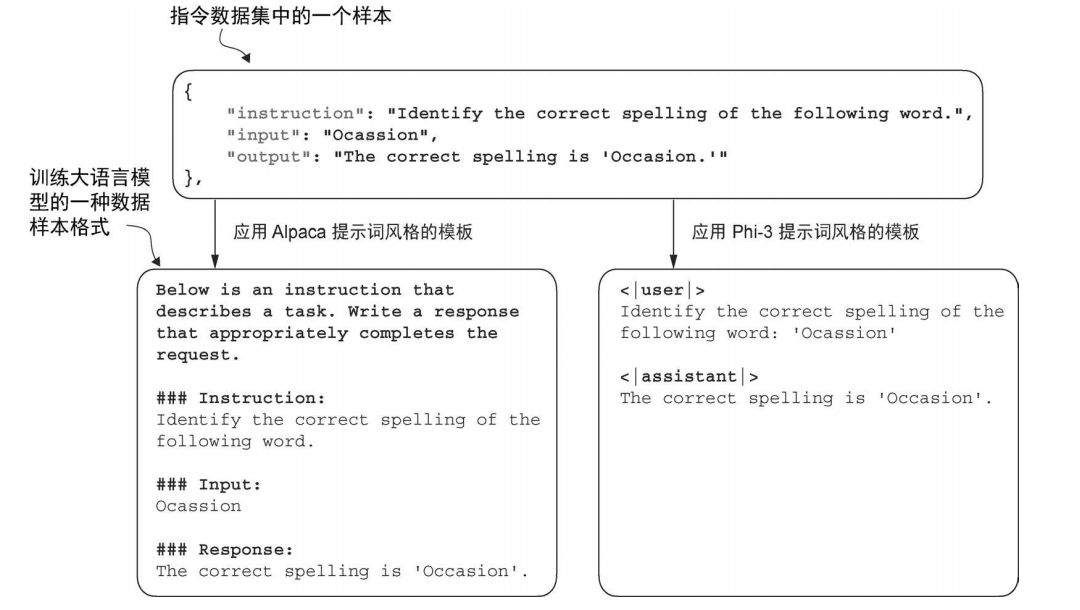

我们将采用 Alpaca 风格的提示词格式，这是指令微调最早使用的原始模板。下面我们将把数据整理成这种格式，作为输入传递给大模型。

In [5]:
def format_input(entry):
    # 构造“Instruction”部分：先给出统一的引导语，再拼接当前样本的 instruction 内容
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    # 如果 entry["input"] 不是空字符串（或非空内容），就添加“Input”部分；否则不添加

    return instruction_text + input_text

先把通用的引导语和样本里的 `instruction` 拼成一段固定结构的文本，并用 `“### Instruction”` 这样的标题把任务说明标出来。然后它判断 `input` 是否为空：如果有内容就追加 `“### Input”` 部分，没有内容就直接省略。这样做的意义在于让所有训练样本都遵循同一种提示词格式，模型更容易稳定地识别“任务描述”和“补充输入”的边界，从而提升指令微调的学习效果与一致性。

带有 `input` 字段的格式化响应示例如下所示。

In [6]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


不包含 input 字段的格式化响应如下。

In [7]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


最后，在下一节准备 PyTorch 的数据加载器之前，我们会先把数据集划分为训练集、验证集和测试集。

In [8]:
train_portion = int(len(data) * 0.85)  # 85%作为训练集
test_portion = int(len(data) * 0.1)    # 10%作为验证集
val_portion = len(data) - train_portion - test_portion  # 剩下5%作为测试集

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [9]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


### 7.3 将数据组织成训练批次

首先，我们将实现一个 `InstructionDataset` 类，用于对数据集中的所有输入进行预先分词（tokenize），这与第 6 章中的 `SpamDataset` 类似。

In [10]:
import torch
from torch.utils.data import Dataset
# 导入 PyTorch 数据集基类，用于自定义数据集


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        # 保存原始样本列表

        self.encoded_texts = []
        # 用于存放每条样本分词后的 token id 序列

        for entry in data:
            instruction_plus_input = format_input(entry)
            # 按统一模板拼出 Instruction +（可选）Input

            response_text = f"\n\n### Response:\n{entry['output']}"
            # 把标注答案作为 Response 部分接在后面

            full_text = instruction_plus_input + response_text
            # 得到一条完整训练文本，提示词 + 标准回答

            self.encoded_texts.append(tokenizer.encode(full_text))
            # 提前分词并保存，训练时直接取用更高效

    def __getitem__(self, index):
        return self.encoded_texts[index]
        # 按索引返回一条已编码样本

    def __len__(self):
        return len(self.data)

和第 6 章一样，我们希望在一个 batch 里同时收集多条训练样本来加速训练，因此需要把同一 batch 内的输入通过 padding 补齐到相近的长度。也同样沿用上一章的做法，我们使用 `<|endoftext|>` 这个 token 作为 padding token。

In [11]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


在第 6 章中，我们把整个数据集里的所有样本都 padding 到同一个长度。这里我们会采用更精细的做法：编写一个自定义的 `collate` 函数并传给 `DataLoader`，让它只在每个 batch 内把样本 padding 到相同长度，而不同 batch 之间可以是不同长度，从而减少无效填充并提高训练效率。

In [12]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    batch_max_length = max(len(item) + 1 for item in batch)
    # 找到本 batch 的最大长度，并额外 +1 预留一个位置

    inputs_lst = []
    # 收集每条样本的张量，最后再堆叠成 batch

    for item in batch:
        new_item = item.copy()
        # 复制一份，避免修改原始数据

        new_item += [pad_token_id]
        # 先在末尾加一个 <|endoftext|>（也用作 padding）

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # 右侧补齐到 batch_max_length

        inputs = torch.tensor(padded[:-1])
        # 去掉最后一个额外位置，保持输入长度一致

        inputs_lst.append(inputs)
        # 保存本样本的输入张量

    inputs_tensor = torch.stack(inputs_lst).to(device)
    # 堆叠成形状 [batch_size, seq_len] 并移动到指定设备

    return inputs_tensor

In [13]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


上面我们只返回了送入大模型的输入，但在训练大模型时还需要对应的targets。和预训练大模型的做法一样，目标值通常是把输入序列整体向右移动一位，让模型学习根据前面的 token 来预测下一个 token。

In [14]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    batch_max_length = max(len(item) + 1 for item in batch)
    # 取本 batch 最大长度并 +1，便于后面做右移目标

    inputs_lst, targets_lst = [], []
    # 分别存放 inputs 和 targets

    for item in batch:
        new_item = item.copy()
        # 复制一份，避免改动原数据

        new_item += [pad_token_id]
        # 末尾补一个 <|endoftext|>，也作为 padding token 使用

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # 右侧 padding 到 batch 内统一长度

        inputs = torch.tensor(padded[:-1])
        # inputs 去掉最后一位

        targets = torch.tensor(padded[1:])
        # targets 向右移动一位，用于预测下一个 token

        inputs_lst.append(inputs)
        # 收集本样本 inputs

        targets_lst.append(targets)
        # 收集本样本 targets

    inputs_tensor = torch.stack(inputs_lst).to(device)
    # 堆叠成 batch 张量并移动到指定设备

    targets_tensor = torch.stack(targets_lst).to(device)
    # 同样得到 targets 的 batch 张量

    return inputs_tensor, targets_tensor

In [15]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


接下来，我们会引入一个名为 `ignore_index` 的特殊取值，用它把所有用于 padding 的 token ID 替换成一个新的数值，这样做的目的，是在计算损失函数（loss）时可以把这些 padding 位置忽略掉，避免它们对训练产生干扰。

具体来说，就是把 padding token 的 ID 50256 替换为 -100，这样损失函数在遇到 -100 时就会跳过这些位置，不把它们计入误差计算。

另外，我们还会加入 `allowed_max_length` 参数，用来在需要时限制样本的最大长度；当你使用自己的数据集且样本长度可能超过 GPT-2 支持的 1024 个 token 上下文窗口时，这个设置会特别有用，因为它可以把过长的样本截断到可训练的范围内。

In [16]:
import torch


def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item) + 1 for item in batch)
    # 本 batch 最大长度 +1，用于构造右移 targets

    inputs_lst, targets_lst = [], []
    # 收集 inputs 与 targets

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        
        mask = targets == pad_token_id
        # 找出 targets 中的 padding 位置

        indices = torch.nonzero(mask).squeeze()
        # padding 的索引位置

        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index
            # 除第一个 padding 外，其余 padding 设为 ignore_index，loss 会忽略

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
            # 截断到最大长度

        inputs_lst.append(inputs)
        # 保存本样本 inputs

        targets_lst.append(targets)
        # 保存本样本 targets

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [17]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


注意：这里不是把所有 50256 都换成 -100，而是只把 targets 里“多余的 padding 位置”换成 -100，用来在 loss 里忽略它们；同时会刻意保留一个 50256，作为这条序列的“结束/停止”信号，让模型学会在合适的位置预测到 `<|endoftext|>`。

我们来看看把 padding 位置替换成 -100 到底能带来什么效果。为了便于说明，假设我们有一个很小的二分类任务，类别标签是 0 和 1，和第 6 章的例子类似。若模型最后一层输出的 logits 如下，那么对应的损失（loss）会按下面的方式计算。

In [18]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  
     [-0.5, 1.5]]  
)
# 构造一个二分类的 logits 示例，每行对应一个样本、两列对应两个类别的打分

targets_1 = torch.tensor([0, 1])
# 两个样本的真实类别标签，分别是 0 和 1

loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
# 用交叉熵计算损失：内部会先对 logits 做 softmax，再根据 targets 取对应类别的概率

print(loss_1)

tensor(1.1269)


现在，如果再加入一个训练样本，损失值也会像预期那样发生变化。

In [19]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # 新增第三个训练样本
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


如果把其中一个样本的类别标签替换成 -100的话。

In [20]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


可以看到，这 3 个训练样本得到的损失和只用前 2 个样本计算出来的损失是一样的，这说明交叉熵损失函数把标签为 `-100` 的那个样本忽略掉了。PyTorch 的 `cross_entropy` 默认就带有 `ignore_index=-100` 的设置，会自动跳过标签为 `-100` 的位置。

利用这个` -100` 的 `ignore_index`，我们就能在 batch 里忽略那些为了对齐长度而额外补出来的 `end-of-text` token，从而避免它们影响训练；但我们又不希望忽略第一个 `end-of-text` token（50256），因为保留它可以让大模型学会在合适的位置“收尾”，也就是知道回答什么时候结束。

### 7.4 创建指令数据集的数据加载器

在本节中，我们将使用 `InstructionDataset` 类和 `custom_collate_fn` 函数来构建训练集、验证集和测试集的 DataLoader。

我们在整理 batch 时就把数据直接移动到目标设备（例如 GPU），而不是等到主训练循环里再移动；当 `custom_collate_fn` 作为 `DataLoader` 的一部分运行时，这个搬运过程可以和数据准备一起并行进行，从而提升整体效率。

接着，我们会用 Python 标准库 `functools` 里的 `partial`，基于原函数创建一个新函数，把原函数的 device 参数预先固定好，这样后续调用时就不需要每次重复传入该参数。

In [21]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


In [22]:
from functools import partial
# 导入 partial，用来“预先固定”函数的一部分参数

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)
# 基于 custom_collate_fn 生成一个新函数：默认把 batch 数据放到 device，并把长度上限限制为 1024

接下来，我们会像前几章一样创建 DataLoader，不同之处在于这一次会为 batch 组装过程传入我们自定义的 collate 函数。

In [23]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 2 
#根据你的设备情况，也可以选择batch_size = 8

torch.manual_seed(123)
train_dataset = InstructionDataset(train_data, tokenizer)
# 用训练数据和分词器构建自定义数据集（内部已预先 tokenize）

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    # 用自定义 collate：padding、生成 targets、ignore_index、并搬到 device

    shuffle=True,
    drop_last=True,
    num_workers=num_workers
    # 指定数据加载并行度
)

In [24]:
val_dataset = InstructionDataset(val_data, tokenizer)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    # 验证时也按 batch 取数据，便于批量计算 loss/指标

    collate_fn=customized_collate_fn,
    # 复用同一个 collate：padding、targets、ignore_index、搬到 device

    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
# 用测试集数据构建数据集对象

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    # 测试时同样按 batch 评估

    collate_fn=customized_collate_fn,
    # 复用同一个 collate，保证处理方式一致

    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

这里把验证集和测试集也单独做成各自的 `Dataset` 和 `DataLoader`，核心逻辑是让训练、验证、测试走同一套数据处理流程，从而保证评估结果是可比的、可信的。我们沿用同一个 `customized_collate_fn`，是为了在三个阶段都用一致的 padding、targets 右移、`ignore_index` 处理和长度截断规则，避免因为“数据打包方式不同”导致指标偏差。

我们来看看最终得到的输入 batch 和目标 batch 的张量维度是什么样的。

In [25]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([2, 61]) torch.Size([2, 61])
torch.Size([2, 55]) torch.Size([2, 55])
torch.Size([2, 58]) torch.Size([2, 58])
torch.Size([2, 58]) torch.Size([2, 58])
torch.Size([2, 62]) torch.Size([2, 62])
torch.Size([2, 47]) torch.Size([2, 47])
torch.Size([2, 76]) torch.Size([2, 76])
torch.Size([2, 54]) torch.Size([2, 54])
torch.Size([2, 67]) torch.Size([2, 67])
torch.Size([2, 73]) torch.Size([2, 73])
torch.Size([2, 50]) torch.Size([2, 50])
torch.Size([2, 55]) torch.Size([2, 55])
torch.Size([2, 68]) torch.Size([2, 68])
torch.Size([2, 51]) torch.Size([2, 51])
torch.Size([2, 61]) torch.Size([2, 61])
torch.Size([2, 68]) torch.Size([2, 68])
torch.Size([2, 65]) torch.Size([2, 65])
torch.Size([2, 53]) torch.Size([2, 53])
torch.Size([2, 54]) torch.Size([2, 54])
torch.Size([2, 57]) torch.Size([2, 57])
torch.Size([2, 57]) torch.Size([2, 57])
torch.Size([2, 72]) torch.Size([2, 72])
torch.Size([2, 60]) torch.Size([2, 60])
torch.Size([2, 59]) torch.Size([2, 59])
torch.Size([2, 58]) torch.

从上面的输出可以看出，所有 batch 的大小都是 2，但序列长度会不同，这与我们的预期一致。接着我们再确认一下输入里是否包含用于 padding 的 `<|endoftext|>` token（其 token ID 为 50256），方法是打印 inputs 这个 batch 中第一条训练样本的内容来检查。

In [26]:
print(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198,  9487,  1958,   428,  6827,   656,   530,
          286,   262,  1708, 10233,    25,  1535,    11,  3773,    11,  3037,
           11,  2647,   198,   198, 21017, 23412,    25,   198, 44132,  5006,
          389,  5854,  2890,   262, 29393,  2831,    13,   198,   198, 21017,
        18261,    25,   198,   464,  7243,   286,   262,  1813,  6827,   318,
         3037,    13], device='mps:0')


同样地，我们也可以通过直接查看内容来确认 targets 中确实包含 -100 这个占位符 token。

In [27]:
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198,  9487,  1958,   428,  6827,   656,   530,   286,
          262,  1708, 10233,    25,  1535,    11,  3773,    11,  3037,    11,
         2647,   198,   198, 21017, 23412,    25,   198, 44132,  5006,   389,
         5854,  2890,   262, 29393,  2831,    13,   198,   198, 21017, 18261,
           25,   198,   464,  7243,   286,   262,  1813,  6827,   318,  3037,
           13, 50256], device='mps:0')


### 7.5 加载预训练的大语言模型

在本节中，我们将使用与第 5 章第 5.5 节以及第 6 章第 6.4 节相同的代码来加载一个预训练的 GPT 模型。不过，这里我们不再加载最小的 1.24 亿参数版本，而是改为加载中等规模的 3.55 亿参数版本，因为 1.24 亿参数的模型容量太小，做指令微调后往往难以得到质量上比较理想的效果。

In [28]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     
    "context_length": 1024,  
    "drop_rate": 0.0,       
    "qkv_bias": True        
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

/Users/wanghaoping/Desktop/LLMs-from-scratch-main/.venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


在下一节开始对模型进行微调之前，我们先看看它在一个验证任务上的表现如何。

In [29]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [30]:
from previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)
# 复用前面章节实现的生成与编码/解码工具函数

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    # 把输入文本转成 token id，作为生成的起始上下文

    max_new_tokens=35,
    # 最多再生成 35 个新 token

    context_size=BASE_CONFIG["context_length"],
    # 使用模型的上下文长度配置，控制可用窗口大小

    eos_id=50256,
)

generated_text = token_ids_to_text(token_ids, tokenizer)
# 把生成得到的 token id 序列解码回可读文本

需要注意的是，我们在前面章节使用的 `generate` 函数返回的是“输入文本 + 生成输出”拼在一起的完整文本，这在之前为了直接展示可读结果时很方便。若要单独取出模型的回答部分，可以从 `generated_text` 的开头去掉指令文本的长度，也就是用输入指令的长度作为切分点来截取后半段内容。

In [31]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


可以看到，模型目前还不能很好地遵循指令：它虽然生成了一个 “Response” 部分，但内容只是重复了原始输入句子以及指令本身。

### 7.6 在指令数据上微调大语言模型

接下来我们将对模型进行微调，我们可以直接复用前面章节已经实现的损失计算与训练相关函数。

In [32]:
from previous_chapters import (
    calc_loss_loader,
    train_model_simple
)

在开始训练之前，我们先计算训练集和验证集的初始损失值（和前面章节一样，我们的目标是让损失尽可能降低）。

In [33]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    # 用训练集的前 5 个 batch 估算当前训练损失
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    # 用验证集的前 5 个 batch 估算当前验证损失

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.7828062057495115
Validation loss: 3.7002222537994385


接下来我们就正式开始对预训练的 GPT 模型做指令微调训练。

In [34]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)
# 运行训练，并定期在验证集上评估与记录损失/已见 token 数

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.807, Val loss 2.718
Ep 1 (Step 000005): Train loss 1.301, Val loss 1.331
Ep 1 (Step 000010): Train loss 0.810, Val loss 1.162
Ep 1 (Step 000015): Train loss 0.859, Val loss 1.089
Ep 1 (Step 000020): Train loss 0.792, Val loss 1.053
Ep 1 (Step 000025): Train loss 0.794, Val loss 1.016
Ep 1 (Step 000030): Train loss 0.748, Val loss 1.000
Ep 1 (Step 000035): Train loss 0.955, Val loss 0.995
Ep 1 (Step 000040): Train loss 0.983, Val loss 0.993
Ep 1 (Step 000045): Train loss 0.661, Val loss 0.987
Ep 1 (Step 000050): Train loss 0.875, Val loss 0.989
Ep 1 (Step 000055): Train loss 0.711, Val loss 0.982
Ep 1 (Step 000060): Train loss 1.053, Val loss 1.010
Ep 1 (Step 000065): Train loss 0.813, Val loss 1.016
Ep 1 (Step 000070): Train loss 0.590, Val loss 0.986
Ep 1 (Step 000075): Train loss 0.634, Val loss 0.986
Ep 1 (Step 000080): Train loss 0.837, Val loss 0.996
Ep 1 (Step 000085): Train loss 0.577, Val loss 0.978
Ep 1 (Step 000090): Train loss 0.664, Val loss

上面的输出可以看出，模型训练得比较顺利：无论是训练损失还是验证损失都在持续下降，这通常意味着模型正在逐步学到数据中的规律。并且从每个 epoch 结束后打印的回复文本也能看到，模型已经能够正确遵循指令，把输入句子 'The chef cooks the meal every day.' 转换成被动语态 'The meal is prepared every day by the chef.'

我们再来查看训练损失和验证损失的变化曲线。

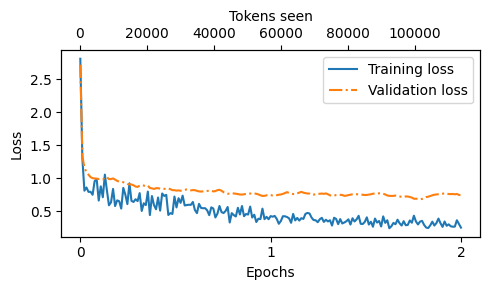

In [35]:
from previous_chapters import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

可以看到，当前模型出现了一些轻微的过拟合迹象，但整体效果仍然不错，已经能够较好地按照指令生成期望的回答。还需要再次提醒的是，由于设备条件有限，这里将 batch size 设为 2 以保证训练能够顺利运行；在你的实际操作中，如果显存或内存允许，建议把 batch size 提高到 4 或 8，通常能带来更稳定的训练过程，并在一定程度上提升最终效果。

同样，如果你在微调过程中遇到内存不足的错误，可以优先把 batch_size 从 8 逐步降低到 4、2，必要时甚至降到 1，以减少单次训练的显存或内存占用。同时，把 `allowed_max_length` 从 1024 下调到 512 或 256 也能显著降低序列带来的开销，通常可以有效缓解内存不足问题并帮助训练顺利运行。

### 7.7 抽取并保存模型回复

在本节中，我们将把测试集上的模型生成结果保存下来，方便在下一节进行评分与评估。同时，我们也会把当前微调后的模型保存一份，以便后续复用。在此之前，我们先简单查看一下微调模型生成的回答效果。

In [36]:
torch.manual_seed(123)


for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = generate(
       
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,

        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    # 去掉输入部分，只保留模型补全的回答文本，并清理模板标记

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud is a cumulus or stratus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is Jane Aust

从测试集里的指令、标准答案以及模型生成的回答对比来看，模型整体表现还是比较不错的。第一条和最后一条指令的回答明显是正确的；但是第二条指令回答出现了偏差。

模型这次的回答主要问题是“概念没有对上”，它把“cloud”当成了“thunderstorm”，然后又在一句话里重复使用了 thunderstorm，导致语义变成了“雷暴是一种云……并且会产生冰雹或雷暴”，这在常识上是不成立的。正确的回答应该明确给出云的类型，比如“cumulonimbus（积雨云）”。

这也说明了指令微调后的大模型评估不像上一章的分类任务那么直接，分类任务只要统计“预测标签对不对”就能得到准确率，而开放式文本回答的好坏往往有灰度空间，既涉及事实是否正确，也涉及表述是否完整、是否贴合指令、是否有细微概念偏差等。实际中，指令微调后的大模型通常会用多种方式评估。

在下一节里，我们会采用类似 AlpacaEval 的思路，用另一个大模型来评估我们模型的回答质量，不过我们不会使用公开基准数据集，而是使用我们自己划分出来的测试集。为此，我们会把模型生成的回答写回到 `test_data` 这个字典中，并保存为 "instruction-data-with-response.json" 文件，方便后续在不同的 Python 会话里加载、复查和进一步分析。

In [37]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    
    input_text = format_input(entry)
    token_ids = generate(
        
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
   
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()
    # 去掉输入部分与模板标记，只保留模型回答

    test_data[i]["model_response"] = response_text
    # 把模型回答写回到测试集数据中，便于后续保存与评估

with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)
    # 保存带模型回答的测试集，indent=4 便于阅读

100%|█████████████████████████████████████████| 110/110 [01:50<00:00,  1.00s/it]


我们来抽查其中一条数据，确认模型生成的回答是否已经被正确添加到 test_data 字典中。

In [38]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


最后，我们也会把模型保存下来，以便将来需要时可以直接复用。

In [39]:
import re


file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


### 7.8 评估微调后的大语言模型

在本节中，我们将借助另一个更大规模的大模型来自动化评估微调后模型的回答质量。具体来说，我们会使用 Meta AI 的指令微调版 Llama 3（80 亿参数）模型，并通过 ollama（https://ollama.com） 在本地运行它来完成评审工作。

Ollama 是一款用于高效运行大语言模型的应用程序。它本质上是对 llama.cpp（https://github.com/ggerganov/llama.cpp） 的封装，而 llama.cpp 用纯 C/C++ 实现了大模型推理，以尽可能提升运行效率。需要注意的是，Ollama 主要用于让大模型生成文本（推理），并不用于训练或微调大模型。在运行下面的代码之前，请先访问 https://ollama.com 按照说明安装 Ollama。

使用 Ollama 搭配 Llama 3 模型大约需要 16 GB 的内存（RAM）。如果你的机器内存不足，可以尝试使用更小的模型，例如运行 `ollama run phi3` 来使用参数量约 38 亿的 Phi-3 模型，它通常只需要大约 8 GB 的内存。本节使用的是phi3模型进行教学演示。

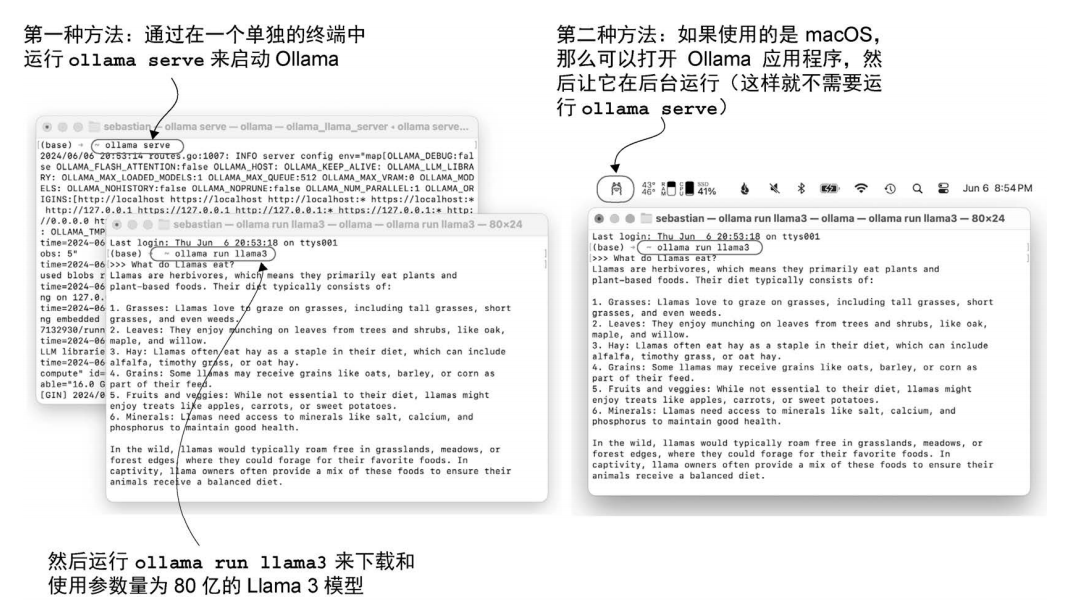

模型下载完成后，你会看到一个命令行提示符，可以直接与模型对话；你可以试试输入类似 “What do llamas eat?” 这样的提示词，模型会返回与下方示例相似的输出。

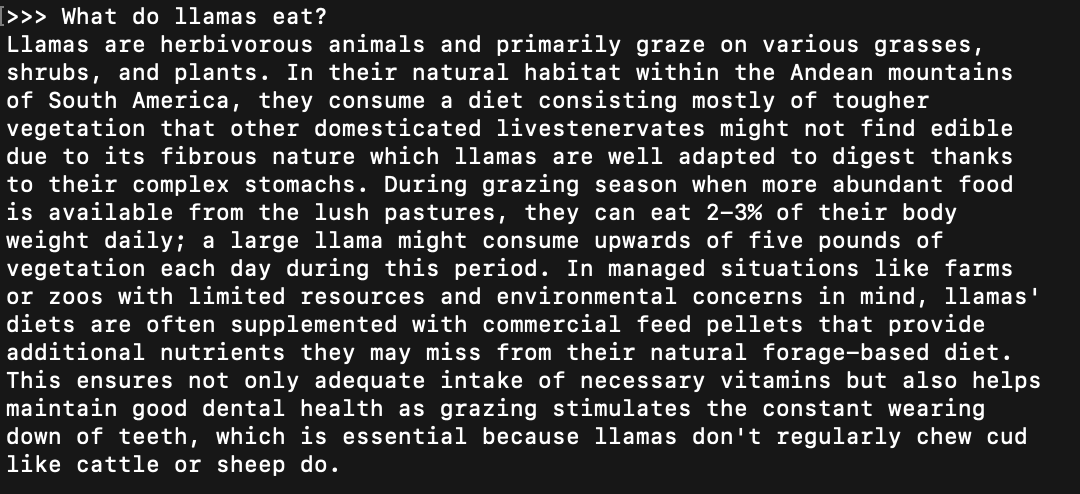

下面这段代码会先检查 Ollama 服务是否正常运行，确认一切无误后，再继续使用 Ollama 来评估我们在上一节生成的测试集回答。

In [40]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


除了前面用 ollama run 在命令行里与模型交互之外，我们还可以通过 Ollama 的 REST API 在 Python 中调用模型

In [41]:
import json
import requests

def query_model(
    prompt,
    model="phi3",
    url="http://localhost:11434/api/chat"
):
    # 组织请求体：指定模型名、对话消息，以及推理参数
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }
    # 通过 POST 请求调用 Ollama 的 REST API，并以流式方式读取返回内容
    
    with requests.post(url, json=data, stream=True, timeout=30) as r:
        r.raise_for_status()
        # 请求失败时直接报错，便于定位问题

        response_data = ""
        # 用于拼接模型逐段返回的文本

        for line in r.iter_lines(decode_unicode=True):
            # Ollama 会按行流式返回 JSON，每行是一段增量结果
            if not line:
                continue

            response_json = json.loads(line)
            if "message" in response_json:
                response_data += response_json["message"]["content"]
                # 累加本次返回的内容片段

    return response_data

model = "phi3"
# 指定要调用的模型名称

result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores and primarily graze on grasses, but they can also consume a variety of other plant materials. Their diet includes:

- Grasses (both native to their habitat in the Andes mountains as well as introduced species)
- Herbs
- Flowers 
- Leaves from shrubs and trees
- Hay or straw when fresh grass is not available, especially during dry seasons
- They are able to digest cellulose thanks to a specialized four-chambered stomach that hosts microorganisms capable of breaking down tough plant fibers. 

Llamas have adapted well to their environment and can survive on sparse vegetation, making them valuable for sustainable land management practices in the Andes region where they are native.


接下来，我们就可以使用上面定义的 `query_model` 函数来评估微调模型的回答质量；我们先从之前查看过的测试集前 3 条回答开始试运行一下。

In [42]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> ### Response: The car zips along like a cheetah chasing its prey.

Score for model response: I would rate this simile-based sentence as an 85 out of 1 endowment, considering that it effectively uses the comparison to convey speed and agility but could have been more vivid or unique in imagery if possible within common knowledge constraints.

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud is a cumulus or stratus cloud.

Score:
>> Score: 25/100

Justification for Score: The provided answer does not accurately complete the request as it fails to identify 'cumulonimbus' clouds which are specifically associated with thunderstorms, instead mentioning cumulus or stratus clouds. Cumulonimbus clouds can indeed produce precipitation and sometimes severe weather like l

可以看到，模型给出的评估整体比较合理，而且当模型答案不完全正确时也会给出部分分数。